In [127]:
# Import required packages
using JuMP, Ipopt, Plots, Printf, LinearAlgebra, SCS, COSMO, Distributions, LightGraphs, FileIO, VideoIO

# Include helper files
include("../twocells/twocells_vis.jl")
include("../twocells/twocells_setup.jl")
include("../twocells/twocells_nonlinearsolver.jl")
include("../twocells/twocells_hittingtime.jl")
include("../utils/ctmc_vis.jl")
include("../utils/ctmc_core.jl")
include("../utils/file_utils.jl")
include("../utils/video_utils.jl")

create_movie (generic function with 1 method)

In [128]:
# Set problem parameters
N = 3  # Number of states - 1
λ = 20.0  # Lambda parameter
initial_tau_val=5.0  # Initial tau value for optimization
initial_P_val=1.0  # Initial P value for optimization


1.0

In [129]:
# Create output directory
lambda_str = replace(string(λ), "." => "_")
base_folder = joinpath(dirname(@__DIR__), "experiments", "results", "Interior_point_method_results")
folder_name = joinpath(base_folder, @sprintf("Interior_Point_Method_results_N_%d_lambda_%s", N, lambda_str))
mkpath(folder_name)

"/Users/ashutoshtripathi/Cellular_Decision_Making/experiments/results/Interior_point_method_results/Interior_Point_Method_results_N_3_lambda_20_0"

In [130]:
# Get state matrices and sizes
S,Skeyer,T,TG,TB,Tc=statematrices(N);
ni,np,ns,nt=varioussizes(N)

# Define state sets
targetstates_good=[target_state+1 for target_state ∈ TG];  # Good target states
targetstates_bad=[target_state+1 for target_state ∈ TB];   # Bad target states
targetstates=[targetstates_good;targetstates_bad]          # All target states
startstates=[start_state+1 for start_state ∈ Tc];         # Starting states
allstates=[startstates;targetstates_good; targetstates_bad]
all_targetstates = vcat(targetstates_good, targetstates_bad)

12-element Vector{Int64}:
  4
 20
 36
 52
 13
 29
 45
 61
 16
 32
 48
 64

In [131]:
# Run nonlinear solver to get optimal solution
upper_bound_tau_0,upper_bound,tau_opt,P_opt,terminationstatus=run_nonlinear_solver(N, λ, initial_P_val, initial_tau_val,false,false)
println("terminationstatus: ", terminationstatus)
println("tau_opt: ", tau_opt)
println("P_opt: ", P_opt)

terminationstatus: LOCALLY_SOLVED
tau_opt: [4.560445566714602, 3.551490965263215, 2.312236821203067, -3.5336607399917864e-29, 3.551490965263215, 6.433898202881866, 7.251084825107669, 7.760777450723159, 2.312236821203067, 7.251084825107668, 9.520376482536765, 12.609806724958169, 4.823745286988005e-28, 7.760777450723159, 12.609806724958169, 20.0, 4.423361571040372, 6.070027911593486, 6.868151994616671, 0.0, 2.3623323972422847, 5.1167115641034, 6.622563121448044, 7.7607774524638735, 1.1769661636642266, 4.100622209960258, 5.9309462185152, 12.609806750630542, -1.2126749115392745e-24, 1.911748145783871, 4.219613491059673, 20.0, 4.423361571040372, 2.3623323972422847, 1.1769661636642266, -2.1983128070794276e-26, 6.070027911593486, 5.1167115641034, 4.100622209960258, 1.911748145783871, 6.868151994616671, 6.622563121448044, 5.9309462185152, 4.219613491059673, 0.0, 7.7607774524638735, 12.609806750630542, 20.0, 7.630952105985402, 7.5817121862073265, 7.498157838445033, 8.60282238610428e-26, 7.58171

In [132]:
# Extract results
tau_opt_tilde = tau_opt[startstates]
lower_bound=minimum(tau_opt_tilde)

# Clean up P_opt values
P_opt_ = P_opt .* (abs.(P_opt) .>= 1e-8)  # Zero out small values
P_opt_ .= min.(P_opt_, 1.0)                # Cap at 1.0
Q_opt = Q_maker_using_M(P_opt_, N, λ, S, Skeyer)  # Generate Q matrix

64×64 Matrix{Float64}:
 -0.991125   0.495562   0.0          0.0      …   0.0       0.0       0.0
  0.0       -2.49556    1.0          0.0          0.0       0.0       0.0
  0.0        0.0       -2.49556      1.0          0.0       0.0       0.0
  0.0        0.0        3.56727e-8  -1.49556      0.0       0.0       0.0
  0.0        0.0        0.0          0.0          0.0       0.0       0.0
  0.0        0.0        0.0          0.0      …   0.0       0.0       0.0
  0.0        0.0        0.0          0.0          0.0       0.0       0.0
  0.0        0.0        0.0          0.0          0.0       0.0       0.0
  0.0        0.0        0.0          0.0          0.0       0.0       0.0
  0.0        0.0        0.0          0.0          0.0       0.0       0.0
  ⋮                                           ⋱                      
  0.0        0.0        0.0          0.0      …   0.0       0.0       0.0
  0.0        0.0        0.0          0.0          0.0       0.0       0.0
  0.0        0.0   

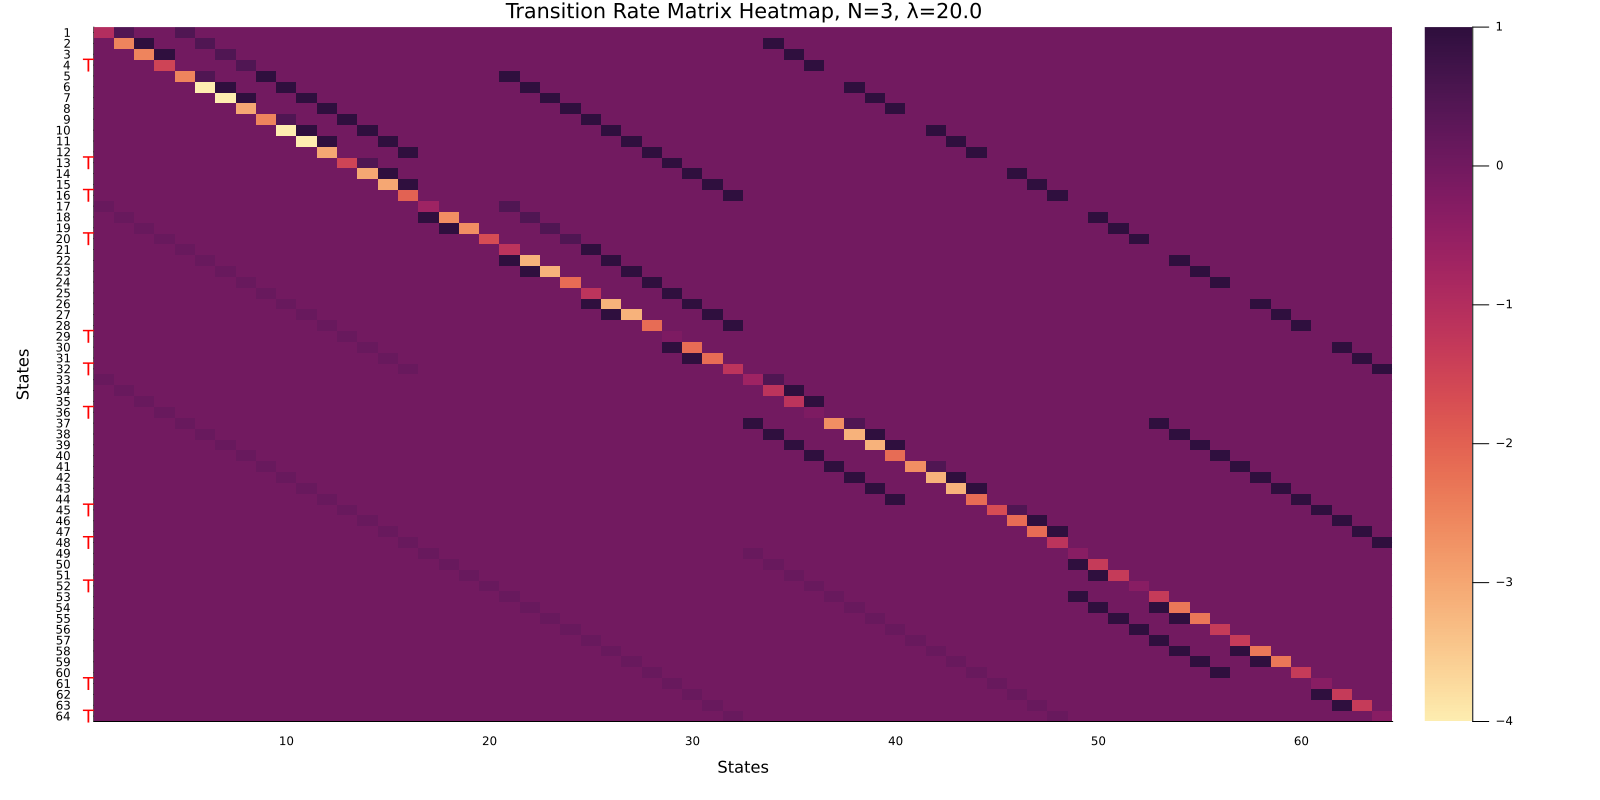

"/Users/ashutoshtripathi/Cellular_Decision_Making/experiments/results/Interior_point_method_results/Interior_Point_Method_results_N_3_lambda_20_0/Q_matrix_heatmap.svg"

In [134]:
# Plot Q matrix heatmap
Q_filename = generate_filename(folder_name,"Q_matrix_heatmap")
plot_Q_with_colored_yticks(Q_opt, N, all_targetstates, Q_filename, λ, save_plots=true)

In [135]:
# Print results for each start state
for start_state_idx in startstates
    println(S[start_state_idx-1],"->",tau_opt[start_state_idx])
end
println(terminationstatus,", Optimal: ", tau_opt[1],", Upper bound: ", upper_bound,", Lower Bound: ",lower_bound)
println("Is Q irreducible? ", is_irreducible(Q_opt))

((0, 0), (0, 0))->4.560445566714602
((0, 0), (1, 0))->3.551490965263215
((0, 0), (2, 0))->2.312236821203067
((1, 0), (0, 0))->3.551490965263215
((1, 0), (1, 0))->6.433898202881866
((1, 0), (2, 0))->7.251084825107669
((1, 0), (3, 0))->7.760777450723159
((2, 0), (0, 0))->2.312236821203067
((2, 0), (1, 0))->7.251084825107668
((2, 0), (2, 0))->9.520376482536765
((2, 0), (3, 0))->12.609806724958169
((3, 0), (1, 0))->7.760777450723159
((3, 0), (2, 0))->12.609806724958169
((0, 0), (0, 1))->4.423361571040372
((0, 0), (1, 1))->6.070027911593486
((0, 0), (2, 1))->6.868151994616671
((1, 0), (0, 1))->2.3623323972422847
((1, 0), (1, 1))->5.1167115641034
((1, 0), (2, 1))->6.622563121448044
((1, 0), (3, 1))->7.7607774524638735
((2, 0), (0, 1))->1.1769661636642266
((2, 0), (1, 1))->4.100622209960258
((2, 0), (2, 1))->5.9309462185152
((2, 0), (3, 1))->12.609806750630542
((3, 0), (1, 1))->1.911748145783871
((3, 0), (2, 1))->4.219613491059673
((0, 1), (0, 0))->4.423361571040372
((0, 1), (1, 0))->2.362332

In [136]:
# Simulate CTMC
initial_state = 1
T = 100.0
println("absorbing states: ", all_targetstates)
Q_opt_copy = copy(Q_opt)
Q_opt_absorbing=Q_absorbing_states_maker(Q_opt_copy, all_targetstates)
println("determinant of Q_opt_absorbing: ", det(Q_opt_absorbing))
times, states = simulate_ctmc(Q_opt, initial_state, T)
times_absorbing, states_absorbing = simulate_ctmc(Q_opt_absorbing, initial_state, T)

absorbing states: [4, 20, 36, 52, 13, 29, 45, 61, 16, 32, 48, 64]
determinant of Q_opt_absorbing: 0.0


([0.0, 1.381636978347921, 4.415330314819003, 5.686975080431399, 100.0], [1, 5, 9, 13, 13])

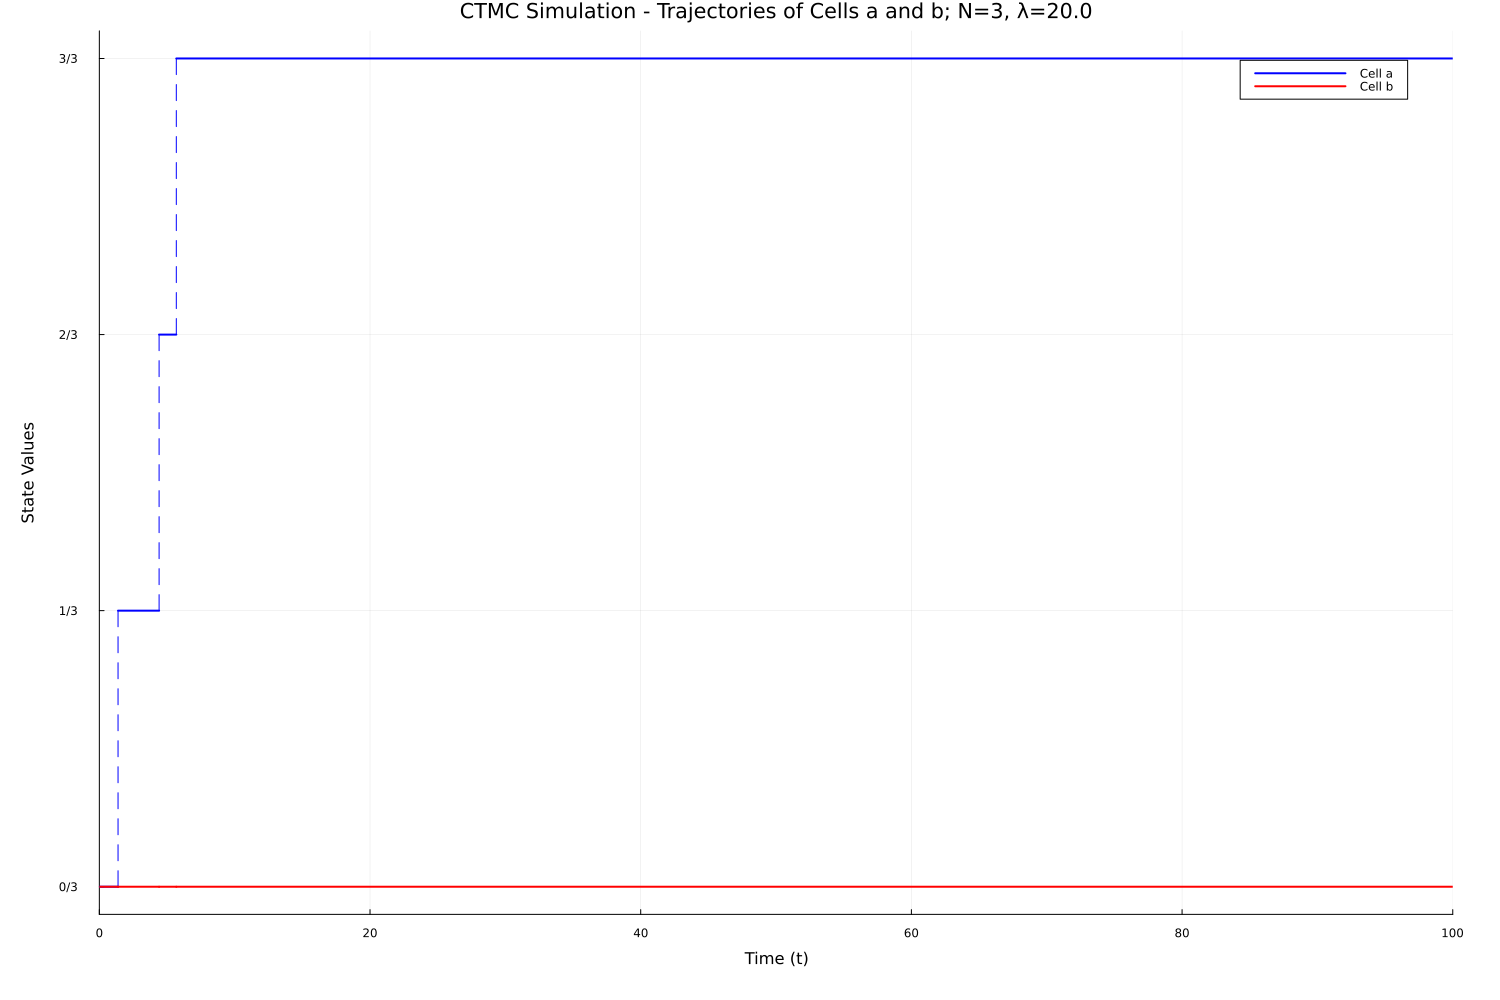

Plotting single ctmc simulation...


"/Users/ashutoshtripathi/Cellular_Decision_Making/experiments/results/Interior_point_method_results/Interior_Point_Method_results_N_3_lambda_20_0/single_ctmc_simulation.svg"

In [137]:
# Plot single CTMC simulation
println("Plotting single ctmc simulation...")
ctmc_simulation_filename = generate_filename(folder_name,"single_ctmc_simulation")
plot_ctmc_our_problem(times_absorbing, states_absorbing, T, N, ctmc_simulation_filename, λ, save_plots=true)

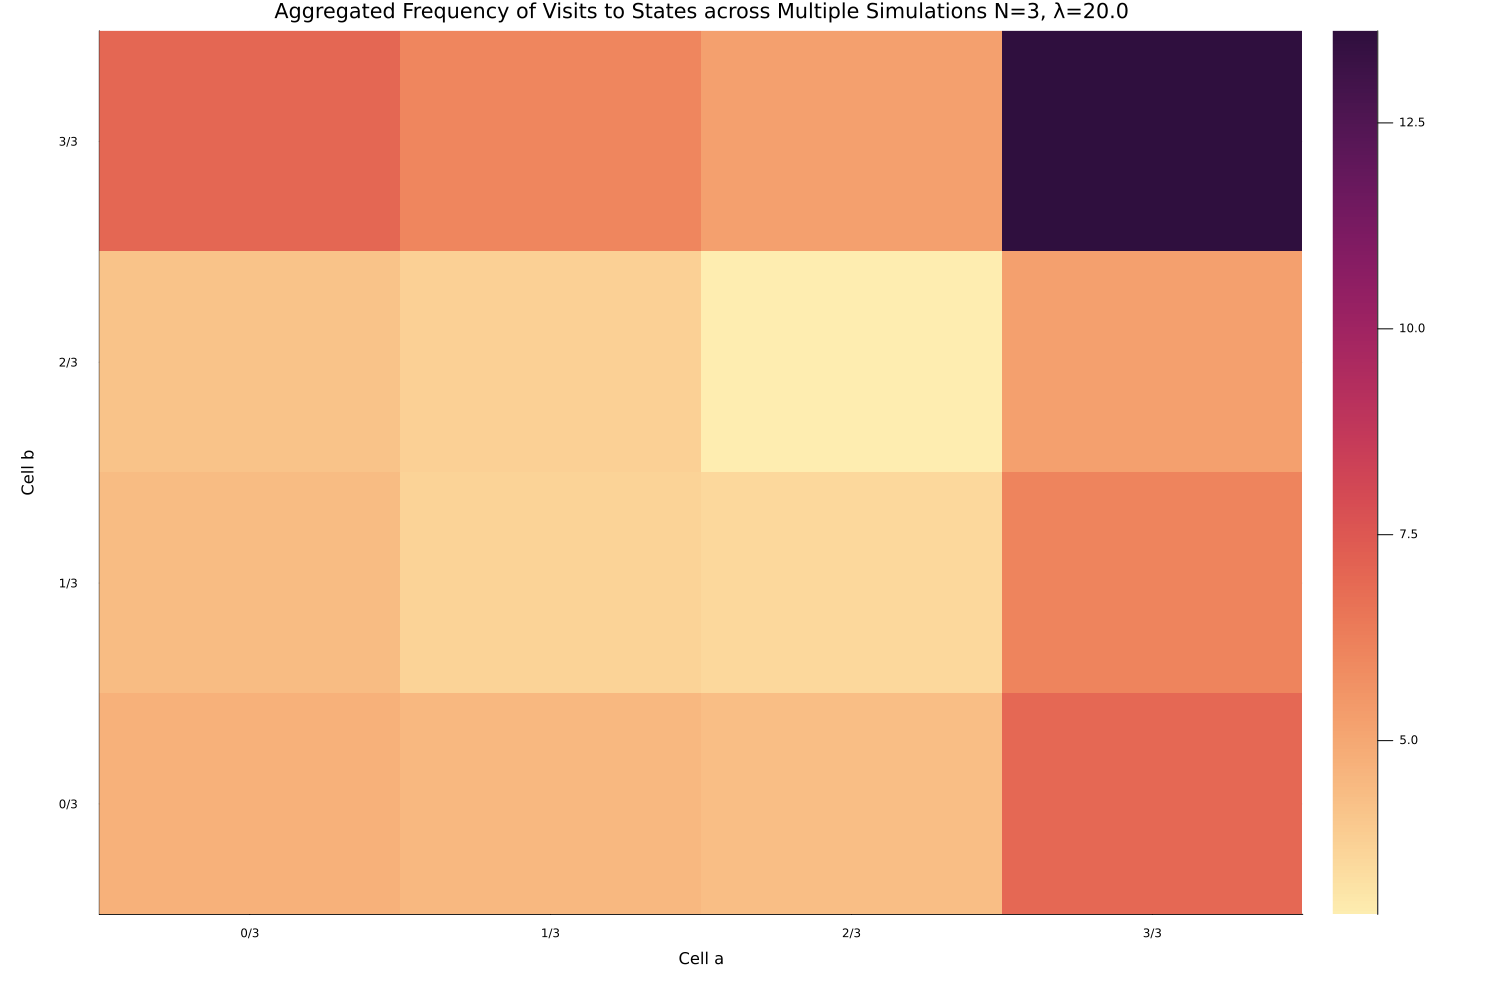

Plotting multiple ctmc simulation...


"/Users/ashutoshtripathi/Cellular_Decision_Making/experiments/results/Interior_point_method_results/Interior_Point_Method_results_N_3_lambda_20_0/multiple_ctmc_simulation_heatmap_longtime.svg"

In [138]:
# Parameters for multiple simulations
num_simulations = 100
T=1000.0
initial_state = 1

# Plot multiple CTMC simulations
println("Plotting multiple ctmc simulation...")
T = 7000.0
longtime_heatmap_simulation_filename = generate_filename(folder_name,"multiple_ctmc_simulation_heatmap_longtime")
plot_ctmc_our_problem_multi(Q_opt, initial_state, T, N, num_simulations, longtime_heatmap_simulation_filename, λ, save_plots=true)


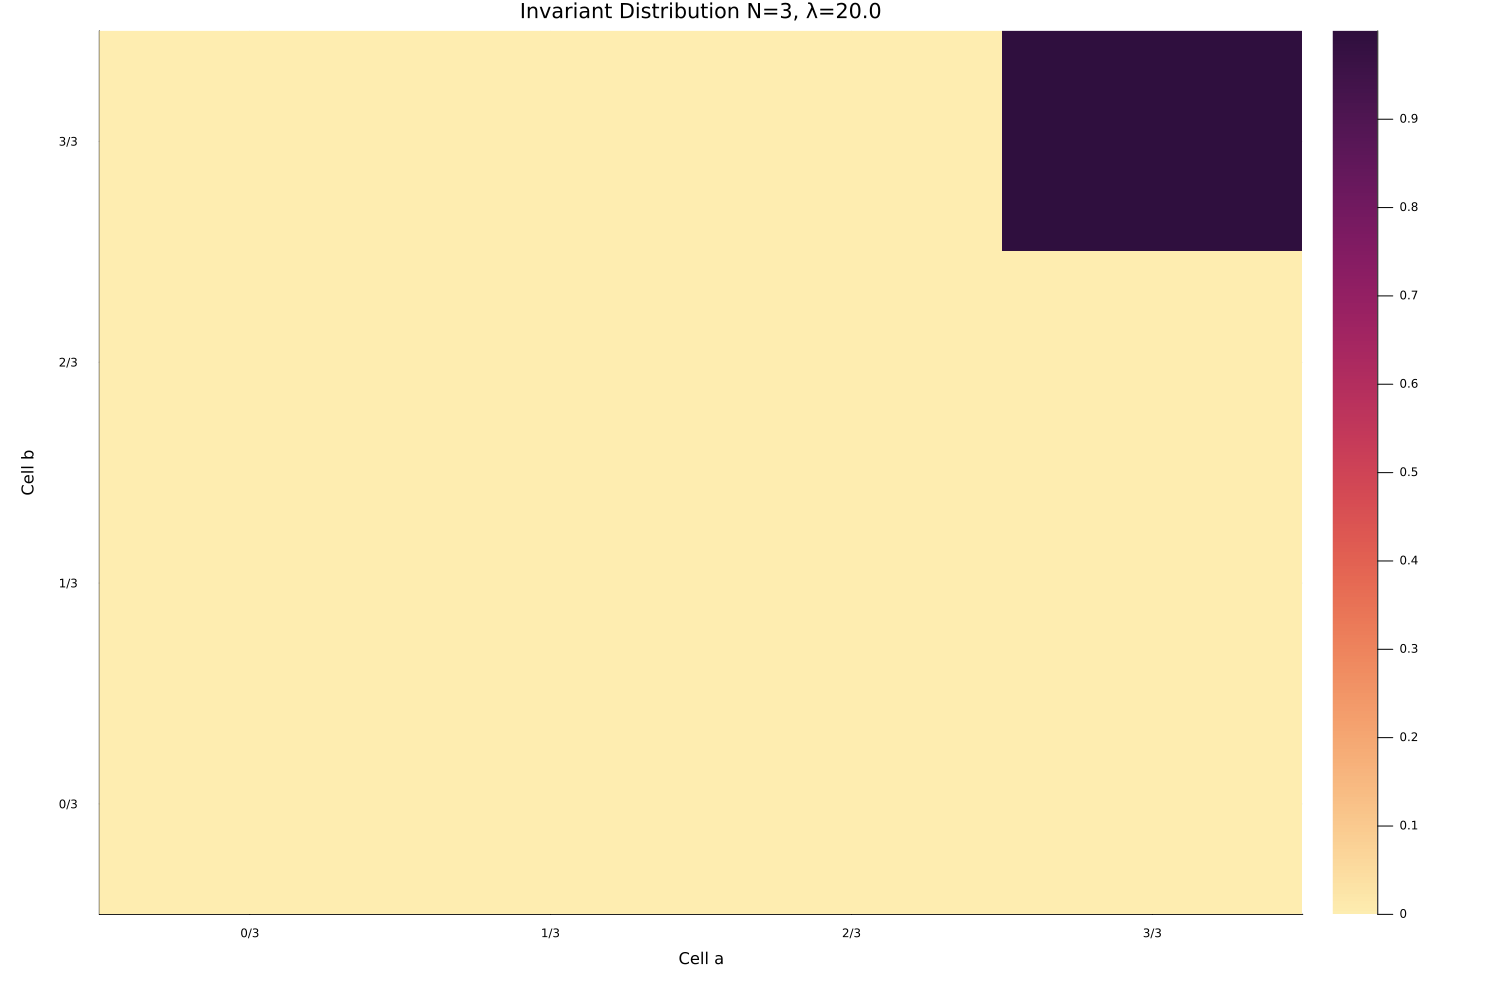

Plotting invariant ctmc heatmap...


"/Users/ashutoshtripathi/Cellular_Decision_Making/experiments/results/Interior_point_method_results/Interior_Point_Method_results_N_3_lambda_20_0/invariant_ctmc_heatmap.svg"

In [139]:
# Plot invariant distribution
println("Plotting invariant ctmc heatmap...")
invariant_heatmap_simulation_filename = generate_filename(folder_name,"invariant_ctmc_heatmap")
plot_ctmc_invar_distn_our_problem(Q_opt, N, invariant_heatmap_simulation_filename, λ, save_plots=true)


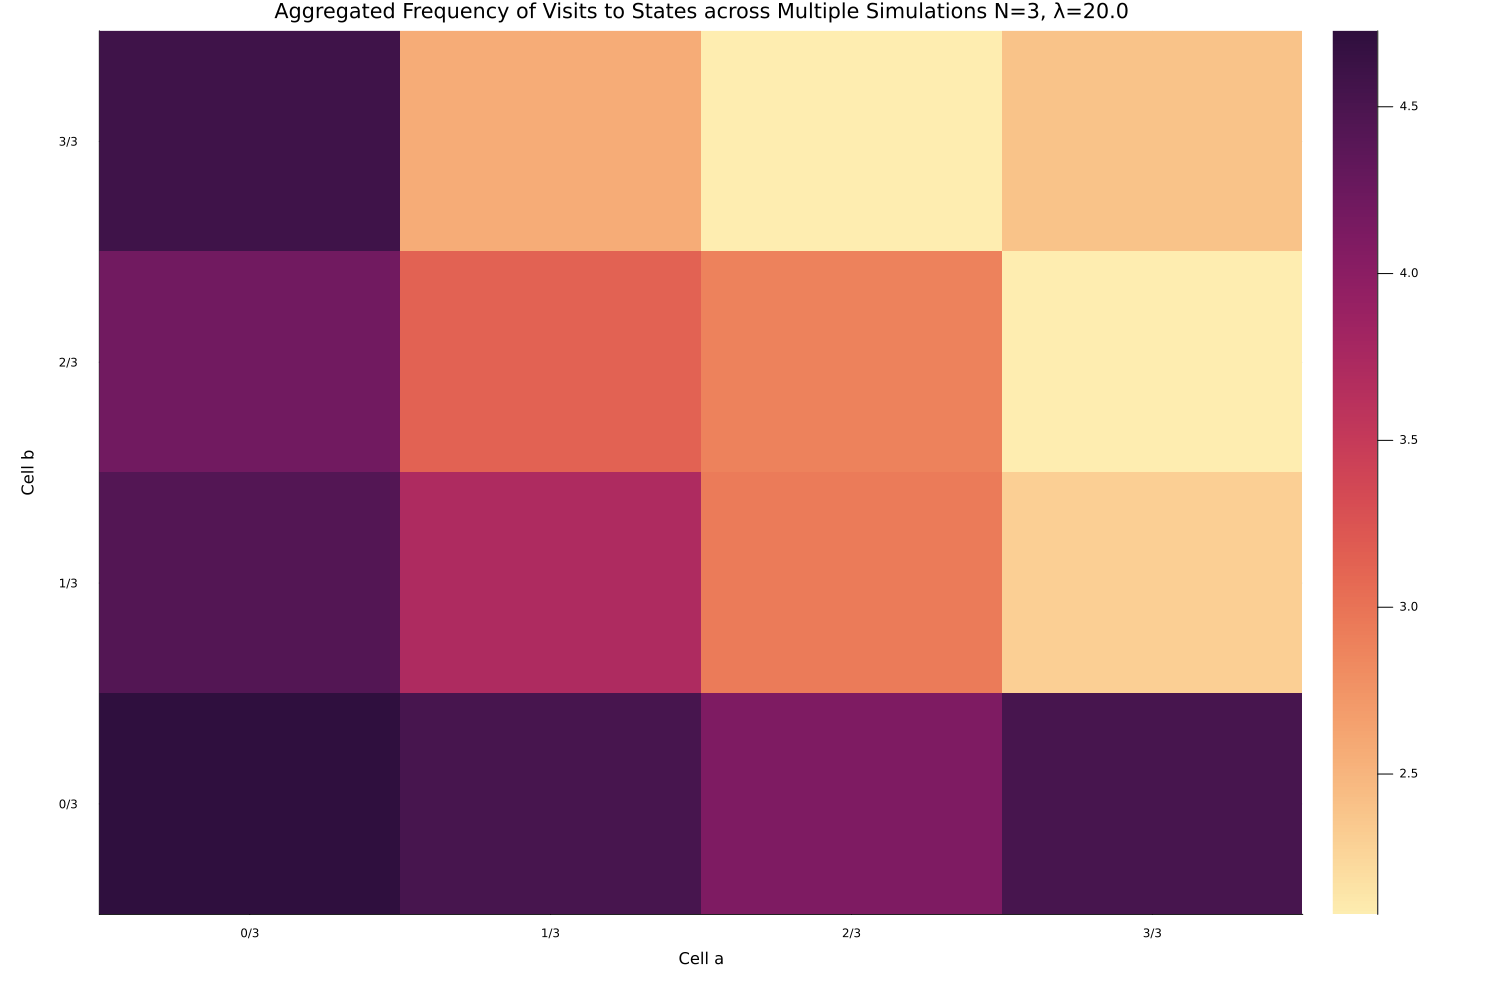

Plotting multiple ctmc simulation with absorbing states...


"/Users/ashutoshtripathi/Cellular_Decision_Making/experiments/results/Interior_point_method_results/Interior_Point_Method_results_N_3_lambda_20_0/multiple_ctmc_simulation_heatmap_longtime_absorbing.svg"

In [146]:
# Plot multiple CTMC simulations with absorbing states
println("Plotting multiple ctmc simulation with absorbing states...")
T = 10000000.0
longtime_heatmap_simulation_filename = generate_filename(folder_name,"multiple_ctmc_simulation_heatmap_longtime_absorbing")
plot_ctmc_our_problem_multi(Q_opt_absorbing, initial_state, T, N, num_simulations, longtime_heatmap_simulation_filename, λ, save_plots=true)


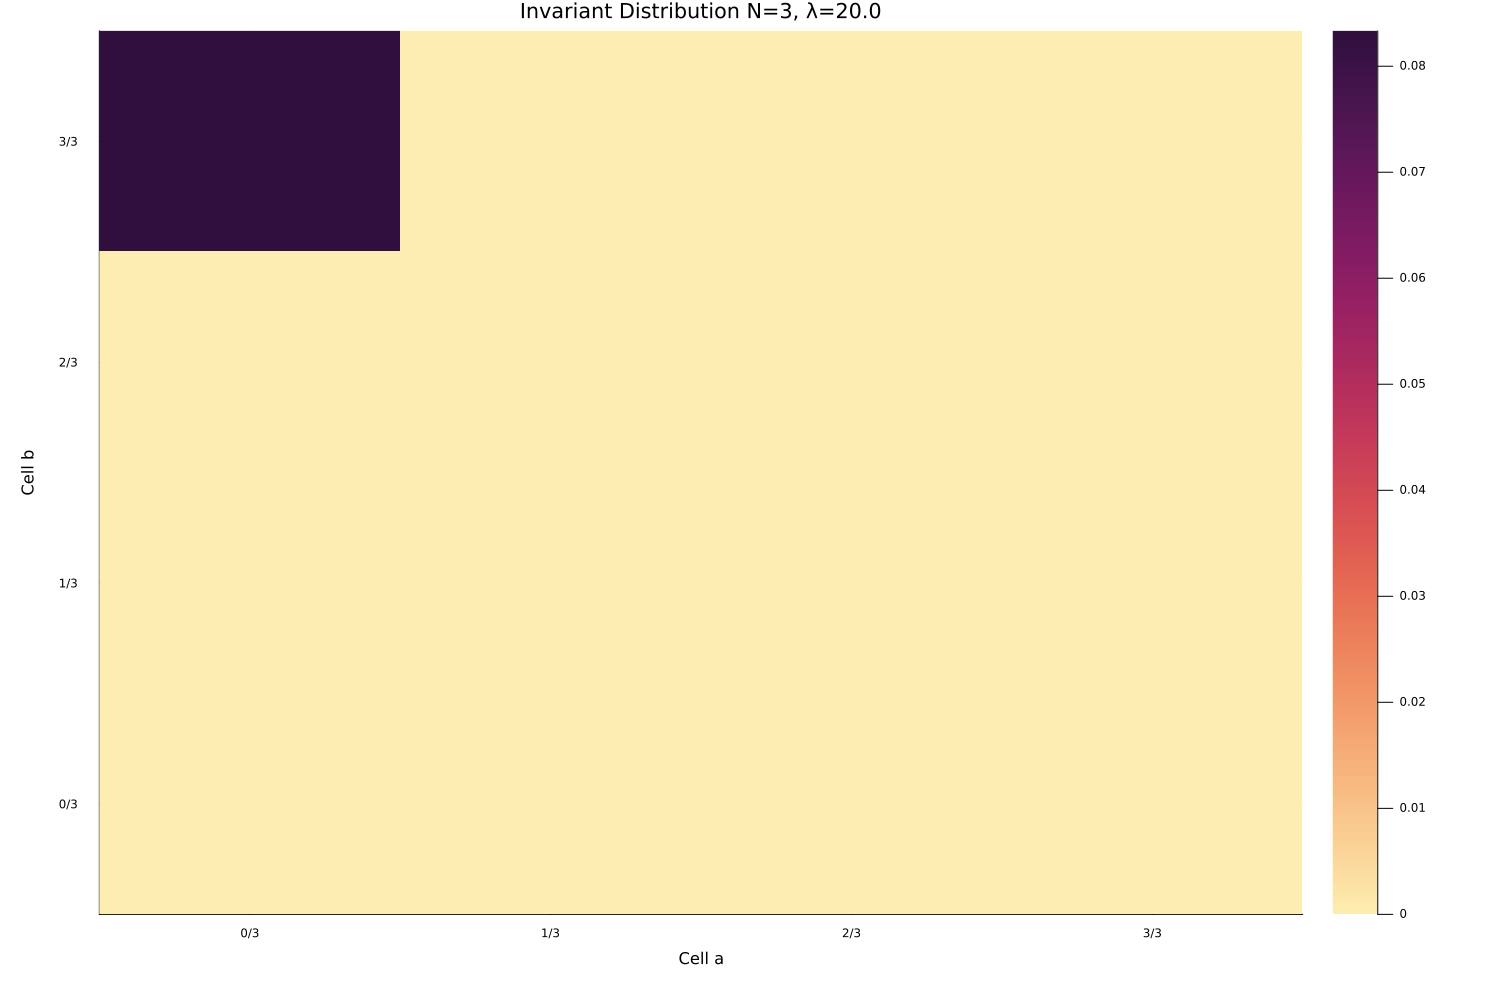

Plotting invariant ctmc heatmap with absorbing states...


"/Users/ashutoshtripathi/Cellular_Decision_Making/experiments/results/Interior_point_method_results/Interior_Point_Method_results_N_3_lambda_20_0/invariant_ctmc_heatmap_absorbing.svg"

In [141]:
# Plot invariant distribution with absorbing states
println("Plotting invariant ctmc heatmap with absorbing states...")
invariant_heatmap_simulation_filename = generate_filename(folder_name,"invariant_ctmc_heatmap_absorbing") 
plot_ctmc_invar_distn_our_problem(Q_opt_absorbing, N, invariant_heatmap_simulation_filename, λ, save_plots=true)

In [142]:
# Print final optimal solution details
# Print to console
println("================================================")
println("Optimal solution")
println("P_opt: ", P_opt_)
println("tau_opt_0: ", tau_opt[1])
println("------------------------------------------------")
println("F^+(.,0): ", P_opt_[1:(N)])
println("F^+(.,1): ", P_opt_[N+1:2*(N)])
println("F^-(.,0): ", P_opt_[2*(N)+1:3*(N)])
println("F^-(.,1): ", P_opt_[3*(N)+1:4*(N)])
println("G: ", P_opt_[4*(N)+1:end-1])
println("k_off: ", P_opt_[end])

# Save to txt file
optimal_values_filename = generate_filename(folder_name, "optimal_values_w_o_fixed_values.txt")
open(optimal_values_filename, "w") do io
    println(io, "tau_opt_0 = ", tau_opt[1])
    println(io, "k_off = ", P_opt_[end])
    println(io, "F+(.,0) = ", P_opt_[1:N])
    println(io, "F+(.,1) = ", P_opt_[N+1:2*N])
    println(io, "F-(.,0) = ", P_opt_[2*N+1:3*N])
    println(io, "F-(.,1) = ", P_opt_[3*N+1:4*N])
    println(io, "G = ", P_opt_[4*N+1:end-1])
end

Optimal solution
P_opt: [0.4955624372097615, 1.0, 1.0, -0.0, -0.0, -0.0, -0.0, -0.0, 3.567270190266809e-8, 1.0, 0.9999999946159154, -0.0, -0.0, 1.0, 1.0, 1.0, 0.15588024560918448]
tau_opt_0: 4.560445566714602
------------------------------------------------
F^+(.,0): [0.4955624372097615, 1.0, 1.0]
F^+(.,1): [-0.0, -0.0, -0.0]
F^-(.,0): [-0.0, -0.0, 3.567270190266809e-8]
F^-(.,1): [1.0, 0.9999999946159154, -0.0]
G: [-0.0, 1.0, 1.0, 1.0]
k_off: 0.15588024560918448
